In [1]:
import pandas as pd
import os
import numpy as np

In [2]:
import geopandas as gpd

In [3]:
import seaborn as sns

In [4]:
base = os.path.join(os.getcwd(),'..','grid_test')

In [5]:
shapefile_path = os.path.join(os.getcwd(),'..','shape','lpj_grid_iowa.shp')
gdf = gpd.read_file(shapefile_path)

In [6]:
outPath = os.path.join(base,'samplefiles')
os.makedirs(outPath,exist_ok=True)

In [7]:
df = pd.read_csv(os.path.join(base,'pixel_count.csv'))

In [8]:
df.drop(columns=['system:index','.geo'],inplace=True)

In [9]:
df['percent']=df['sum']/66000*100

In [10]:
grid_test= gdf.copy()
for d in range(2010,2020):
    temp = df[df['year']==d]
    temp.drop(columns=['year','sum'],inplace=True)
    temp.rename(columns={'percent':str(d)},inplace=True)
    grid_test = grid_test.merge(temp,on='Id', how='left')

In [11]:
grid_lt10p = grid_test.copy()

In [12]:
def map_p(x,p1,p2):
    x = np.where(x>p1,x,np.nan)
    x = np.where(x<=p2,x,np.nan)
    return x
    

In [13]:
grid_lt10p = grid_lt10p.set_index('Id')

In [15]:
for d in range(2010,2020):
    d = str(d)
    # grid_lt10p[d] = map_p(grid_lt10p[d],10)

In [16]:
grid_10t20p = grid_test.copy()
for d in range(2010,2020):
    d = str(d)
    grid_10t20p[d] = map_p(grid_10t20p[d],10,20)
grid_10t20p.to_file(os.path.join(outPath,'Pixel_10t20p.shp'))

In [17]:
grid_20t30p = grid_test.copy()
for d in range(2010,2020):
    d = str(d)
    grid_20t30p[d] = map_p(grid_20t30p[d],20,30)
grid_20t30p.to_file(os.path.join(outPath,'Pixel_20t30p.shp'))

In [18]:
grid_30t40p = grid_test.copy()
for d in range(2010,2020):
    d = str(d)
    grid_30t40p[d] = map_p(grid_30t40p[d],30,40)
grid_30t40p.to_file(os.path.join(outPath,'Pixel_30t40p.shp'))

In [19]:
grid_40t50p = grid_test.copy()
for d in range(2010,2020):
    d = str(d)
    grid_40t50p[d] = map_p(grid_40t50p[d],40,50)
grid_40t50p.to_file(os.path.join(outPath,'Pixel_40t50p.shp'))

In [20]:
grid_50t60p = grid_test.copy()
for d in range(2010,2020):
    d = str(d)
    grid_50t60p[d] = map_p(grid_50t60p[d],50,60)
grid_50t60p.to_file(os.path.join(outPath,'Pixel_50t60p.shp'))

In [21]:
grid_60t70p = grid_test.copy()
for d in range(2010,2020):
    d = str(d)
    grid_60t70p[d] = map_p(grid_60t70p[d],60,70)
grid_60t70p.to_file(os.path.join(outPath,'Pixel_60t70p.shp'))

In [22]:
grid_70t80p = grid_test.copy()
for d in range(2010,2020):
    d = str(d)
    grid_70t80p[d] = map_p(grid_70t80p[d],70,80)
grid_70t80p.to_file(os.path.join(outPath,'Pixel_70t80p.shp'))

In [23]:
grid_gt80 = grid_test.copy()
for d in range(2010,2020):
    d = str(d)
    grid_gt80[d] = map_p(grid_gt80[d],80,100)
grid_gt80.to_file(os.path.join(outPath,'Pixel_gt80p.shp'))

In [24]:
# grid_lt10p.to_file(os.path.join(outPath,'Pixel_lt10p.shp'))

<Axes: >

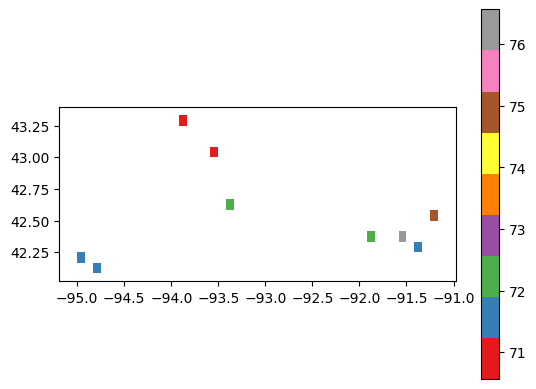

In [30]:
grid_70t80p.plot('2014',cmap='Set1',legend=True)

<Axes: >

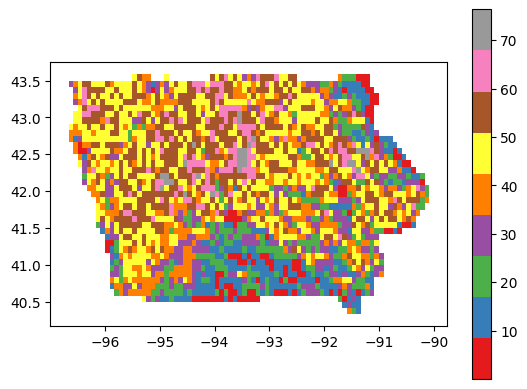

In [26]:
grid_test.plot('2012',cmap='Set1',legend=True)